## Load

In [4]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from src.config import FEATURES_CSV
df = pd.read_csv(FEATURES_CSV)
df.head()

,pdb_id,protein,variant,morphology,n_protofilaments,label,source,notes,length,frac_hydrophobic,...,plddt_mean,plddt_median,frac_disordered,ss_helix,ss_sheet,ss_coil,sasa_total,sasa_hydrophobic,sasa_polar,sasa_hydrophobic_frac
0,9KAL,Alpha-synuclein,WT,single,1,0,Cryo-EM,Single protofilament,140,0.385714,...,NaN,NaN,0.0,0.650000,0.000000,0.350000,14827.285542,5715.487502,9111.798040,0.385471
1,6XYO,Alpha-synuclein,WT,multi,2,1,MSA patient,MSA Type I doublet,140,0.385714,...,NaN,NaN,0.0,0.650000,0.000000,0.350000,14827.285542,5715.487502,9111.798040,0.385471
2,7P6A,Tau,3R,single,1,0,Pick's disease,Single protofilament (verified clean),441,0.251701,...,NaN,NaN,0.0,0.019789,0.286280,0.693931,99038.222976,24419.760465,74618.462511,0.246569
3,5O3L,Tau,3R/4R,multi,2,1,Alzheimer's disease,Paired helical filament (PHF) doublet,73,0.287671,...,NaN,NaN,0.0,0.019789,0.286280,0.693931,99038.222976,24419.760465,74618.462511,0.246569
4,9IAH,Beta-lactoglobulin,WT,single,1,0,Cryo-EM,Single protofilament,34,0.558824,...,NaN,NaN,0.0,0.061798,0.224719,0.713483,10757.707021,3273.698094,7484.008928,0.304312


## Sanity check feature distributions by class

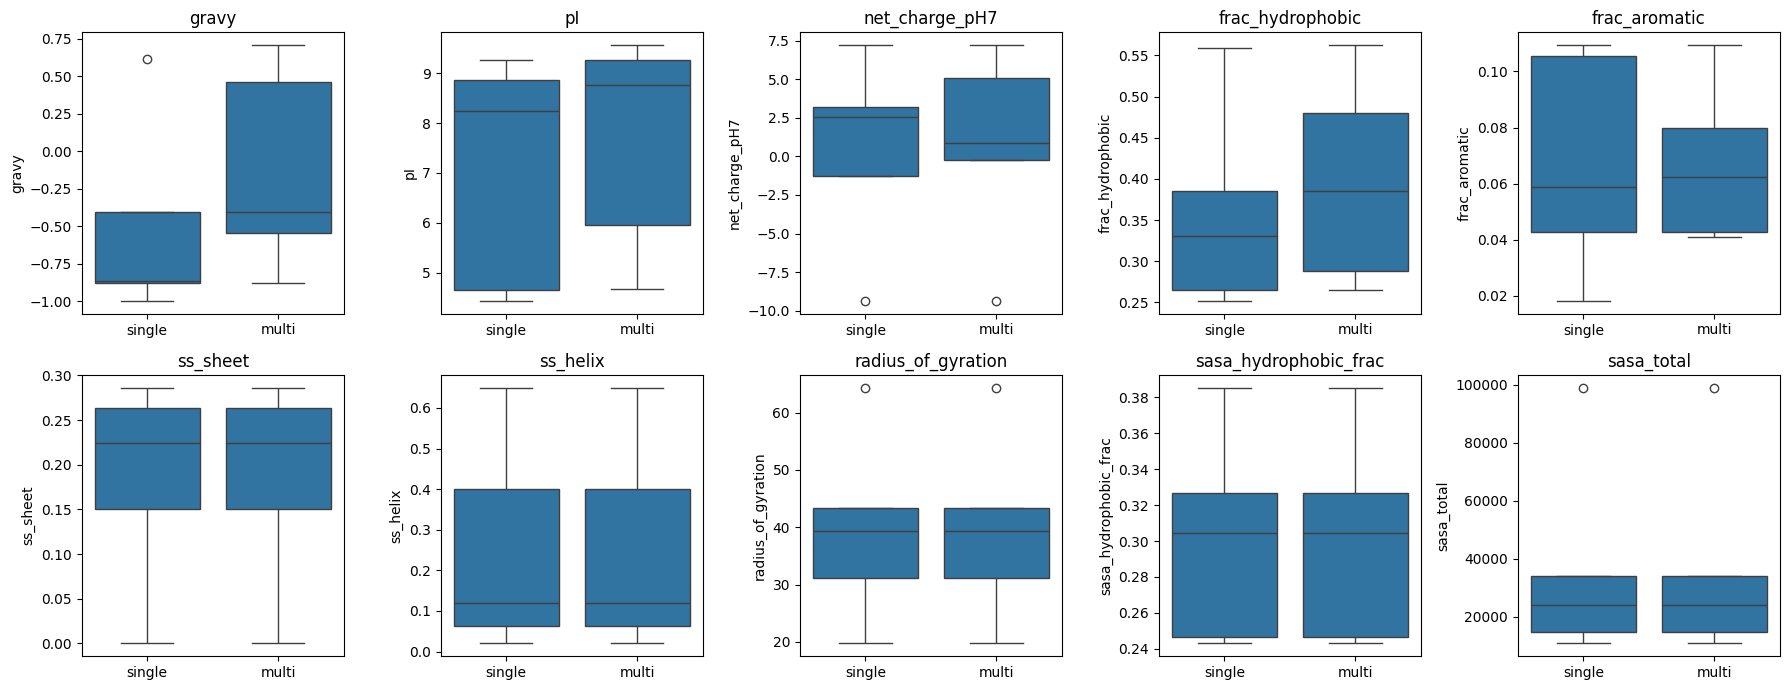

In [5]:
feature_cols = [
    # Physicochemical (§5)
    "gravy",
    "pI",
    "net_charge_pH7",
    "frac_hydrophobic",
    "frac_aromatic",
    # Structural — secondary structure & geometry (§5)
    "ss_sheet",
    "ss_helix",
    "radius_of_gyration",
    # Structural — solvent accessibility (§5)
    "sasa_hydrophobic_frac",
    "sasa_total",
]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.flat, feature_cols):
    sns.boxplot(data=df, x="morphology", y=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.savefig("../results/feature_distributions.png", dpi=150)

## Correlation heatmap

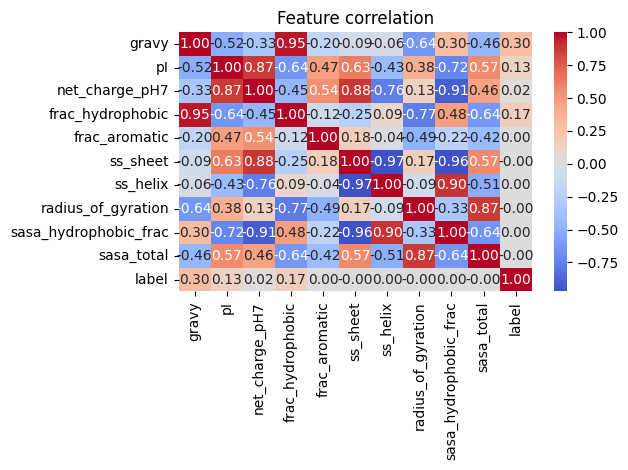

In [6]:
import numpy as np
num = df[feature_cols + ["label"]].dropna()
sns.heatmap(num.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Feature correlation"); plt.tight_layout()
plt.savefig("../results/feature_correlation.png", dpi=150)